In [1]:
#import csv from github
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

facebook_df = pd.read_csv('https://raw.githubusercontent.com/Dinahak/dk-facebook-regression/refs/heads/main/Facebook_Advertising_Data%20(1).csv')
facebook_df

,Unnamed: 0,Impressions,Clicks,Spent,success,y,z,M,7,10,...,Amount_Purchased_1-5,Amount_Purchased_5-10,Amount_Purchased_10-20,Amount_Purchased_20-50,Amount_Purchased_50-100,Amount_Clicked_1-5,Amount_Clicked_5-10,Amount_Clicked_10-20,Amount_Clicked_20-50,Amount_Clicked_50-100
0,0,7350,1,1.430000,1,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
1,1,17861,2,1.820000,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,2,693,0,0.000000,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,3,4259,1,1.250000,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,4,4133,1,1.290000,1,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1133,1138,1129773,252,358.189997,1,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
1134,1139,637549,120,173.880003,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1135,1140,151531,28,40.289999,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1136,1141,790253,135,198.710001,1,0,1,0,0,0,...,1,0,0,0,0,0,1,0,0,0


In [2]:
facebook_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1138 entries, 0 to 1137
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               1138 non-null   int64  
 1   Impressions              1138 non-null   int64  
 2   Clicks                   1138 non-null   int64  
 3   Spent                    1138 non-null   float64
 4   success                  1138 non-null   int64  
 5   y                        1138 non-null   int64  
 6   z                        1138 non-null   int64  
 7   M                        1138 non-null   int64  
 8   7                        1138 non-null   int64  
 9   10                       1138 non-null   int64  
 10  15                       1138 non-null   int64  
 11  16                       1138 non-null   int64  
 12  18                       1138 non-null   int64  
 13  19                       1138 non-null   int64  
 14  20                      

In [3]:
#remove unnamed row
facebook_df = facebook_df.drop(columns=['Unnamed: 0'])

In [4]:
print(facebook_df.columns)


Index(['Impressions', 'Clicks', 'Spent', 'success', 'y', 'z', 'M', '7', '10',
       '15', '16', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27',
       '28', '29', '30', '31', '32', '36', '63', '64', '65', '66', '100',
       '101', '102', '103', '104', '105', '106', '107', '108', '109', '110',
       '111', '112', '113', '114', '35-39', '40-44', '45-49',
       'Amount_Purchased_1-5', 'Amount_Purchased_5-10',
       'Amount_Purchased_10-20', 'Amount_Purchased_20-50',
       'Amount_Purchased_50-100', 'Amount_Clicked_1-5', 'Amount_Clicked_5-10',
       'Amount_Clicked_10-20', 'Amount_Clicked_20-50',
       'Amount_Clicked_50-100'],
      dtype='object')


In [5]:
facebook_df.shape

(1138, 59)

In [6]:
#we will use the columns impression ,clicks ,spent and success
facebook_df2 = facebook_df[['Impressions','Clicks','Spent']]
facebook_df2


,Impressions,Clicks,Spent
0,7350,1,1.430000
1,17861,2,1.820000
2,693,0,0.000000
3,4259,1,1.250000
4,4133,1,1.290000
...,...,...,...
1133,1129773,252,358.189997
1134,637549,120,173.880003
1135,151531,28,40.289999
1136,790253,135,198.710001


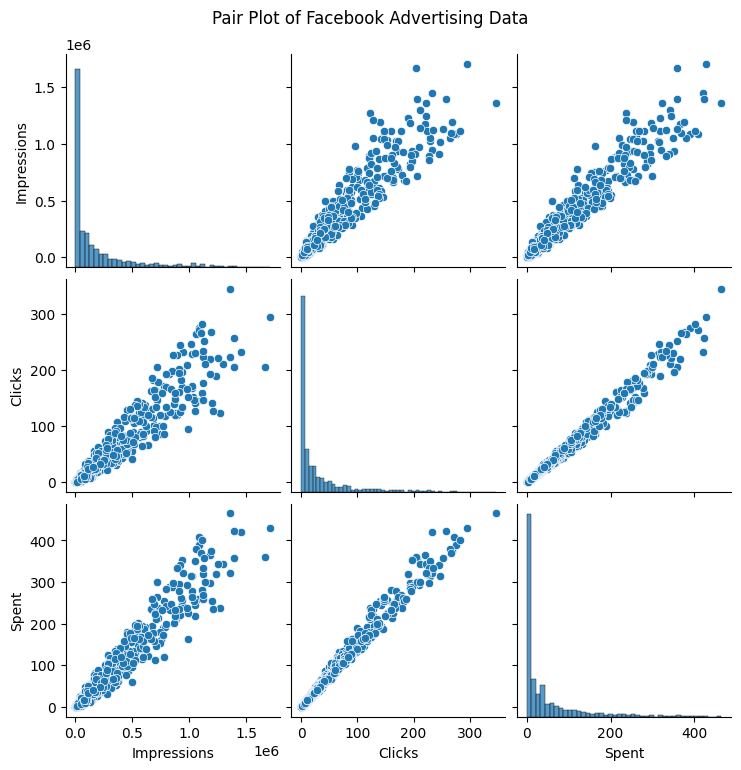

             Impressions    Clicks     Spent
Impressions     1.000000  0.954133  0.972410
Clicks          0.954133  1.000000  0.993319
Spent           0.972410  0.993319  1.000000


In [10]:
#Vusualize the rlshp btwn variables
sns.pairplot(facebook_df2)
plt.suptitle('Pair Plot of Facebook Advertising Data', y=1.02)
plt.show()

#correlation matrix
corr_matrix = facebook_df2.corr()
print(corr_matrix)

In [21]:
#OLS regression results
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

# Add a constant to the independent variables
X = facebook_df2[['Impressions', 'Clicks']]
y = facebook_df2['Spent']
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())

# Make predictions using the statsmodels model
y_pred_sm = model.predict(X)

#define r2
r2_sm = r2_score(y, y_pred_sm)
mse_sm = mean_squared_error(y, y_pred_sm)

print(f"\nStatsmodels R-squared: {r2_sm}")
print(f"Statsmodels Mean Squared Error: {mse_sm}")


                            OLS Regression Results                            
Dep. Variable:                  Spent   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 8.624e+04
Date:                Sat, 03 May 2025   Prob (F-statistic):               0.00
Time:                        17:34:02   Log-Likelihood:                -3742.0
No. Observations:                1138   AIC:                             7490.
Df Residuals:                    1135   BIC:                             7505.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.1941      0.228     -0.852      

In [ ]:
#change to html
!jupyter nbconvert --to html facebook_regression.ipynb